## Завдання 1
Підготуйте та завантажте дані.
 - Збережіть у CSV-файл 10-15 текстових відгуків клієнтів (англійською мовою).
 - Завантажте дані за допомогою pandas.
 - Обробіть тексти: приведіть до нижнього регістру, видаліть спецсимволи та цифри.
 - Перевірте кількість рядків і середню довжину відгуків (у словах).

In [1]:
import pandas as pd
import re

reviews = {
    "review": [
        "The product is amazing and works perfectly!",
        "Very bad customer service, I am disappointed.",
        "Fast delivery and excellent quality.",
        "The application crashes sometimes but overall is good.",
        "I love this product! Highly recommended.",
        "Terrible experience, the package arrived damaged.",
        "Good value for the price.",
        "The interface is simple and user friendly.",
        "Battery life is too short and performance is slow.",
        "Excellent support team and quick response.",
        "The design looks modern and professional.",
        "I am not satisfied with the quality.",
        "Works exactly as expected, great job!",
        "Shipping was delayed for several days.",
        "Fantastic experience, I will buy again."
    ]
}

df = pd.DataFrame(reviews)

df.to_csv("customer_reviews.csv", index=False)

In [3]:
data = pd.read_csv("customer_reviews.csv")

print("\nПочаткові дані:")
data.head()


Початкові дані:


,review
0,The product is amazing and works perfectly!
1,"Very bad customer service, I am disappointed."
2,Fast delivery and excellent quality.
3,The application crashes sometimes but overall ...
4,I love this product! Highly recommended.


In [4]:
def clean_text(text):
    text = text.lower()                 
    text = re.sub(r'[^a-z\s]', '', text)  
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data["clean_review"] = data["review"].apply(clean_text)

print("\nОчищені тексти:")
data[["review", "clean_review"]].head()


Очищені тексти:


,review,clean_review
0,The product is amazing and works perfectly!,the product is amazing and works perfectly
1,"Very bad customer service, I am disappointed.",very bad customer service i am disappointed
2,Fast delivery and excellent quality.,fast delivery and excellent quality
3,The application crashes sometimes but overall ...,the application crashes sometimes but overall ...
4,I love this product! Highly recommended.,i love this product highly recommended


In [5]:
row_count = len(data)

average_length = data["clean_review"].apply(
    lambda x: len(x.split())
).mean()

print("\nКількість рядків:", row_count)
print("Середня довжина відгуків:", round(average_length, 2), "слів")


Кількість рядків: 15
Середня довжина відгуків: 6.47 слів


## Завдання 2
Застосуйте токенізацію і видаліть стоп-слова.
 - Розділіть тексти на токени за допомогою nltk.word_tokenize.
 - Видаліть стоп-слова з бібліотеки nltk.corpus.stopwords.
 - Видаліть усі токени довжиною менше 3 символів.
 - Підрахуйте загальну кількість токенів до і після очищення.



In [10]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt_tab')
nltk.download('stopwords')

data["tokens_before"] = data["clean_review"].apply(word_tokenize)
tokens_before_count = data["tokens_before"].apply(len).sum()


[nltk_data] Downloading package punkt_tab to /home/antik/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/antik/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    filtered_tokens = []

    for word in tokens:
        if word not in stop_words and len(word) >= 3:
            filtered_tokens.append(word)

    return filtered_tokens

data["tokens_after"] = data["tokens_before"].apply(remove_stopwords)

In [15]:
tokens_after_count = data["tokens_after"].apply(len).sum()

print("Токени ДО очищення:\n")
print(data["tokens_before"].head())

print("\nТокени ПІСЛЯ очищення:\n")
print(data["tokens_after"].head())

print("\nЗагальна кількість токенів ДО очищення:", tokens_before_count)
print("Загальна кількість токенів ПІСЛЯ очищення:", tokens_after_count)

Токени ДО очищення:

0    [the, product, is, amazing, and, works, perfec...
1    [very, bad, customer, service, i, am, disappoi...
2            [fast, delivery, and, excellent, quality]
3    [the, application, crashes, sometimes, but, ov...
4        [i, love, this, product, highly, recommended]
Name: tokens_before, dtype: object

Токени ПІСЛЯ очищення:

0                [product, amazing, works, perfectly]
1              [bad, customer, service, disappointed]
2                [fast, delivery, excellent, quality]
3    [application, crashes, sometimes, overall, good]
4                [love, product, highly, recommended]
Name: tokens_after, dtype: object

Загальна кількість токенів ДО очищення: 97
Загальна кількість токенів ПІСЛЯ очищення: 61


## Завдання 3
 - Побудуйте частотний словник і візуалізуйте результати.
 - Використовуйте collections.Counter для підрахунку зустрічальності слів.
 - Виведіть 15 найчастіших слів та їхню кількість.
 - Побудуйте горизонтальну діаграму за допомогою matplotlib:

|Слово|Частота|
|-|-|
|Якість|...|
|продукт|...|
|Якість|...|

 - Підпишіть осі та }аголовок графіка (Top 15 Frequent Words).
 - Збережіть зображення як feedback_word_freq.png.

In [17]:
from collections import Counter
import matplotlib.pyplot as plt

all_words = []

for tokens in data["tokens_after"]:
    all_words.extend(tokens)

word_freq = Counter(all_words)
top_words = word_freq.most_common(15)

print("Топ 15 найчастіших слів:\n")

for word, count in top_words:
    print(f"{word}: {count}")

Топ 15 найчастіших слів:

product: 2
works: 2
excellent: 2
quality: 2
good: 2
experience: 2
amazing: 1
perfectly: 1
bad: 1
customer: 1
service: 1
disappointed: 1
fast: 1
delivery: 1
application: 1


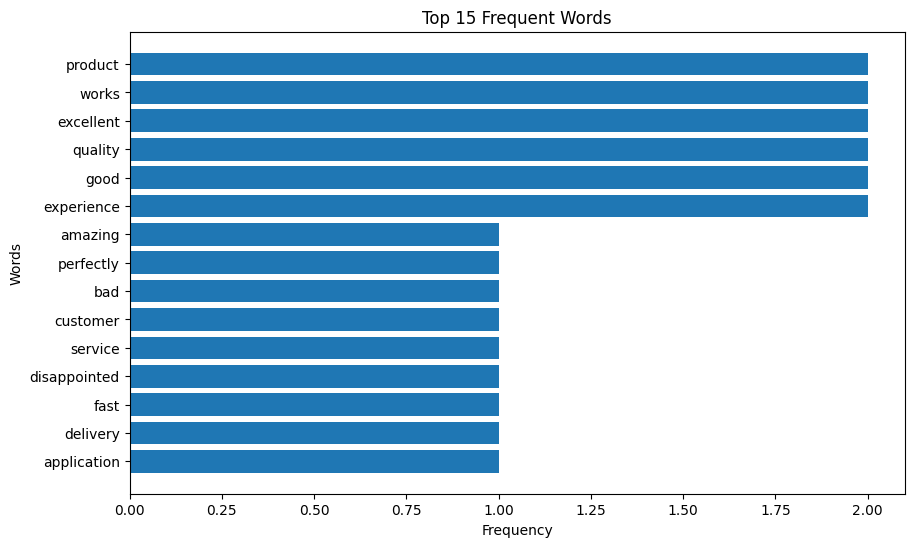

In [18]:
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 6))

plt.barh(words, counts)

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 15 Frequent Words")

plt.gca().invert_yaxis()

plt.savefig("feedback_word_freq.png")

plt.show()

## Завдання 4
Додатковий аналіз біграм.
 - Згенеруйте біграми (послідовності з двох слів) за допомогою nltk.bigrams.
 - Підрахуйте частоту появи біграм.
 - Відобразіть 10 найчастіших біграм у вигляді таблиці:

|Біграма|Частота|
|-|-|
|дуже добре|...|
|хороша якість|...|
|непогано|...|


 - Збережіть результати в CSV-файл feedback_bigrams.csv.


In [19]:
from nltk import bigrams
from collections import Counter
import pandas as pd

all_bigrams = []

for tokens in data["tokens_after"]:
    review_bigrams = list(bigrams(tokens))
    all_bigrams.extend(review_bigrams)

In [21]:
bigram_freq = Counter(all_bigrams)

top_bigrams = bigram_freq.most_common(10)

In [22]:
bigram_table = pd.DataFrame(
    top_bigrams,
    columns=["Bigram", "Frequency"]
)

bigram_table["Bigram"] = bigram_table["Bigram"].apply(
    lambda x: " ".join(x)
)

bigram_table

,Bigram,Frequency
0,product amazing,1
1,amazing works,1
2,works perfectly,1
3,bad customer,1
4,customer service,1
5,service disappointed,1
6,fast delivery,1
7,delivery excellent,1
8,excellent quality,1
9,application crashes,1


In [23]:
bigram_table.to_csv("feedback_bigrams.csv", index=False)